# Human in the Loop

## At a high level:
#### - Human in the loop (HITL): you pause the graph, a human looks at what the agent is about to do, then decides whether and how to continue. 

#### - Breakpoints: predefined pause points in the graph where execution stops so a human can inspect/approve/modify state before continuing. 

## Review
We laid the foundations for this with streaming. For human-in-the-loop, we often want to see our graph outputs as its running.

### Advantages: human-in-the-loop:

#### (1) Approval - We can interrupt our agent, surface state to a user, and allow the user to accept an action
#### (2) Debugging - We can rewind the graph to reproduce or avoid issues
#### (3) Editing - You can modify the state

## Methods: LangGraph offers several ways to get or update agent state to support various human-in-the-loop workflows.
One among them is *'Breakpoints'* -  which provide a simple way to stop the graph at specific steps. We can use this for user approval.


## Build an agent with tool usage
Goal: Needs human approval for tool usage

##### Method: Compile the graph with interrupt_before=["tools"] where tools is our tools node.\
##### Meaning - This means that the execution will be interrupted before the node 'tools', which executes the tool call.

### EX: build an agent that can perform arithmatic operation

In [1]:
# set up envirnment and LLm agent
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"
                                         

In [2]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)                                         

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [3]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content                                       

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbH5d3OTBLqyNzTt6DwI6Jy7KqgGdhUlRM+M8F8fJAzeWrnlaw9gMNUMbpjzklE'}}]

In [5]:
# define tools for addition, subtraction , multiplication and division

def addition(a:float, b:float)->float:
    """ Add the two parameters a and b 
    Args:
    a:first float
    b:second float  """
    return a+b

def multiply(a:float, b:float)->float:
    """ Multiply the two parameters a and b 
    Args:
    a:first float
    b:second float  
    """
    return a*b
    
def subtract(a:float, b:float)->float:
    """ subtract the parameter a from b
    Args:
    a:first float
    b:second float  
    """
    return a-b

def division(a:float, b:float)->float:
    """ Divide the parameters a by b 
    Args:
    a:first float
    b:second float  
    """
    return a/b

# List tools
tools = [addition, subtract, multiply, division]

#bind tool to LLM
llm_with_tools = llm.bind_tools(tools)


### Build graph with tool calling and temporary memory and Breakpoint at tools node

In [6]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

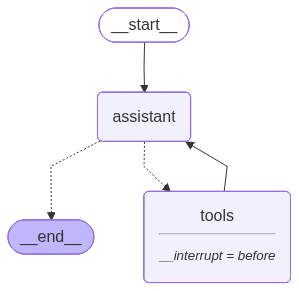

In [7]:
from langchain_core.messages import SystemMessage,HumanMessage, AIMessage 
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# define nodes

Sys_inst = [SystemMessage(content="You are a helpful assistant who uses the tools to perform arithmatic operations")]

# node 1
def assistant(state:MessagesState):
    messages = Sys_inst +state['messages']
    
    response = llm_with_tools.invoke(messages)
    #print("\nLLM: ", response)
    return {'messages':[response]}

# LangGraph autocreates tool nodes with toolNode function

# build graph with nodes and edges
builder = StateGraph(MessagesState)

# add nodes
builder.add_node('assistant' , assistant)
builder.add_node('tools', ToolNode(tools))

# add edges with condition fucntion tools_conition
builder.set_entry_point('assistant')
# If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
 # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
builder.add_conditional_edges('assistant', tools_condition)
builder.add_edge('tools', 'assistant')
builder.add_edge('assistant', END)

# compile graph with checkp[ointer for memory and breakpoint at tools node.
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [8]:
# create a thread and stream values
config = {'configurable':{'thread_id' : '11'}}

input_msg = [HumanMessage(content="Multiply 10 and 10")]

# Run the graph until the first interruption
events=[]
for event in graph.stream({'messages': input_msg},config , stream_mode="values"):
    events.append(event)
    print("\n",event, end="\n ")



 {'messages': [HumanMessage(content='Multiply 10 and 10', additional_kwargs={}, response_metadata={}, id='092c52c1-5308-4b57-ae4c-b9c81e664497')]}
 
 {'messages': [HumanMessage(content='Multiply 10 and 10', additional_kwargs={}, response_metadata={}, id='092c52c1-5308-4b57-ae4c-b9c81e664497'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 10, "b": 10}'}, '__gemini_function_call_thought_signatures__': {'a5b70ee7-7a5b-468b-b9b8-5cf7e2889eb9': 'EjQKMgEMOdbHmAbygr3FJwuYlbZcEa9tw/gcIRMIQMXJZ98nxsO/obwkmYYRPjWTEdXSfk60'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ddabf-d181-7a81-87bd-ec8d9ee63b6b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 10, 'b': 10}, 'id': 'a5b70ee7-7a5b-468b-b9b8-5cf7e2889eb9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 293, 'output_tokens': 18, 'total_toke

In [9]:
for m in events:
    for msg in m['messages']:
        msg.pretty_print()

================================ Human Message =================================

Multiply 10 and 10
================================ Human Message =================================

Multiply 10 and 10
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (e73ea789-6249-44ce-9bc7-44f5c6e9e1c5)
 Call ID: e73ea789-6249-44ce-9bc7-44f5c6e9e1c5
  Args:
    a: 10
    b: 10


## Check the state 
##### state =graph.get_state(config) - provides current and most recent checkpoints
- What node is next?
- where is the interruption?

In [10]:
state =graph.get_state(config)
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 10 and 10', additional_kwargs={}, response_metadata={}, id='0a94c987-57ed-4f0f-a0c7-0731b2099c35'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 10, "b": 10}'}, '__gemini_function_call_thought_signatures__': {'e73ea789-6249-44ce-9bc7-44f5c6e9e1c5': 'EoUBCoIBAQw51sdBaRsSTzSWGhHRSUnN5SEzjPKC/7SaJBTch0Y3/lv2INscGOAUFcKgTAkAFCLKG1N6fiKTG3DB+A4uPClq72OO1jjw4ruHRomoPIt/hjOiYTbYkChmjSerNWMc5hsEU6+kSPkWbT151AXXdL9h7SFRYA+B0FrNm1NL5UxYsA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dd75c-d113-72d1-977a-9562a64457d4-0', tool_calls=[{'name': 'multiply', 'args': {'a': 10, 'b': 10}, 'id': 'e73ea789-6249-44ce-9bc7-44f5c6e9e1c5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 293, 'output_tokens': 42, 'total_tokens': 335, 'input_token_de

In [11]:
# check what's next
state.next

('tools',)

In [19]:
#Since thread stores the state history with metdata, lets Re-run the graph 
events =[]
for event in graph.stream(None,config , stream_mode="values"):
    events.append(event)
    print("\n",event, end="\n ")


 {'messages': [HumanMessage(content='Divide 100 by 10 and add 20', additional_kwargs={}, response_metadata={}, id='79d14a41-0309-4640-a5ad-df0dbb015d05')]}
 
 {'messages': [HumanMessage(content='Divide 100 by 10 and add 20', additional_kwargs={}, response_metadata={}, id='79d14a41-0309-4640-a5ad-df0dbb015d05'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'division', 'arguments': '{"a": 100, "b": 10}'}, '__gemini_function_call_thought_signatures__': {'3666ffd4-7100-4ae1-849b-cb035ab7df28': 'EvACCu0CAQw51seOAr5SdndgwDsAoGN2I9fHZyoQSQ64c+wNVGqBWXkae7exkGcQmD1DlzaqrfHKgcHJ5392EmkL97l1/dvR7oJJFUGm4f/Rl02ZI6xcSofXRFBGz1VUDK/mjUUXFpp9L/PB58zBJXYAohhQnXxUX1WhWZhjZsZscwwZ63F61qnS5tLSFrwtAyrmdYtkEuq7ExcB7GjCkr6wBvuagyvFnAAme0KcTtoCukJpd6+vaeeIFJtpU/NFghkSt1gWIgdO7zCmFkkLa13G/SyFVkXMAdiaWx8N8FxjhHqpemPzzQF7aD3AZtOQR7MGT78KukEULp0/rNou2b4nDOQZGTlUZR7nUJZBv0+K2ZOhIIwLCA/0LSobXF31fUzFQJAok/ZFBaD6D0wrl+Zibi2htj/xXnGwhVrW14UjiIGvbQkiHoNY/Qlcq8CjUgONXwGtrL3dUZuE2IrV3bdAOOWUmjxmb

In [29]:
events[-1]['messages'][-1].tool_calls

[{'name': 'division',
  'args': {'a': 100, 'b': 10},
  'id': '3666ffd4-7100-4ae1-849b-cb035ab7df28',
  'type': 'tool_call'}]

# User Approval for tool call
-  lets bring these together with a specific user approval step that accepts user input.
### user approval :
while tool call exists, 


In [10]:
# create a new thread
config = {"configurable":{"thread_id":"7"}}

# run the graph with streaming 'values'
def run_graph(inp_msg):
    events= []
    for event in graph.stream(inp_msg, config, stream_mode="values"):
        events.append(event)
    #print(events)
    return events


# set input message
ip_msg = {'messages': [HumanMessage(content="multiply 100 by 10 and add 200")]}

# streaming stops before the tool node due to breakpoint interrupt_before=["tools"] 
events = run_graph(ip_msg)
tool_call = events[-1]['messages'][-1].tool_calls

while tool_call:
    print(tool_call)
    user_approval = input("Do you want to use the tools?[YES/NO]").lower()
    
    if user_approval == 'yes':
        events = run_graph(None)
        #event[-1]['messages'][-1].pretty_print()
        tool_call = events[-1]['messages'][-1].tool_calls
        
        
    else:
        tool_call = ""
        print("Operation cancelled by the user")

print(events)

[{'name': 'multiply', 'args': {'a': 100, 'b': 10}, 'id': 'caea78d4-e085-465d-b56e-2b238c97a1c5', 'type': 'tool_call'}]


Do you want to use the tools?[YES/NO] YES


[{'name': 'addition', 'args': {'a': 1000, 'b': 200}, 'id': '0e77e564-06df-4486-8e37-fe07c055b3fc', 'type': 'tool_call'}]


Do you want to use the tools?[YES/NO] YES


[{'messages': [HumanMessage(content='multiply 100 by 10 and add 200', additional_kwargs={}, response_metadata={}, id='42d436ac-b493-490e-b39b-6072e20b2bcf'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 100, "b": 10}'}, '__gemini_function_call_thought_signatures__': {'caea78d4-e085-465d-b56e-2b238c97a1c5': 'EjQKMgEMOdbHxakEfxKnRES1AhCsOOVLhW6jftT2S57pcGtqL7cQ7tuRQgDjj1btmyzolPUj'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ddac8-936a-7392-ae89-bb1cb2a1775f-0', tool_calls=[{'name': 'multiply', 'args': {'a': 100, 'b': 10}, 'id': 'caea78d4-e085-465d-b56e-2b238c97a1c5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 300, 'output_tokens': 19, 'total_tokens': 319, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='1000.0', name='multiply', id='f55bc4b4-eb54-4e70-85d6-a35aef0

Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /runs/multipart (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: 2966
API Key: lsv2_********************************************68trace=019ddacb-c904-73b1-b144-795e3ce9a602,id=019ddacb-c913-74a1-b3ff-2b490a9cca0a; trace=019ddacb-c904-73b1-b144-795e3ce9a602,id=019ddacb-e928-7c62-8c2e-2d6246b817d2; trace=019ddacb-c904-73b1-b144-795e3ce9a602,id=019ddacb-e928-7c62-8c2e-2d6246b817d2; trace=019ddacb-c904-73b1-b144-795e3ce9a602,id=019ddacb-c912-78d1-87c6-6b75bb24613a; trace=019ddacb-c904-73b1-b144-795e3ce9a602,id=019ddacb-c904-73b1-b144-